# Initial Dataset preprocessing

In [227]:
import os
import mne
import csv
import pandas as pd
import numpy as np
import json
%matplotlib inline
import matplotlib.pyplot as plt

In [228]:
parsed_path = "./../EEG_data/parsed/"
summary = "./../EEG_data/parsed/summary.csv"
with open(summary, 'r') as csvfile:
    csvreader = csv.DictReader(csvfile,delimiter =';')
    data_list = []
    for row in csvreader:
        data_list.append(row)
folders = []
for data in data_list:
    if (not data["session_id"] in folders):
        folders.append(data["session_id"])

# paths to the parsed dataset files
p_baseline_intervals = []
p_baseline_markers = []
p_baseline_metadata = []
p_baseline_samples = []
p_main_intervals = []
p_main_markers = []
p_main_metadata = []
p_main_samples = []

for folder in folders:
    p_baseline_intervals.append(parsed_path + folder + "/baseline_intervals.parquet")
    p_baseline_markers.append(parsed_path + folder + "/baseline_markers.parquet")
    p_baseline_metadata.append(parsed_path + folder + "/baseline_metadata.json")
    p_baseline_samples.append(parsed_path + folder + "/baseline_samples.parquet")

    p_main_intervals.append(parsed_path + folder + "/main_intervals.parquet")
    p_main_markers.append(parsed_path + folder + "/main_markers.parquet")
    p_main_metadata.append(parsed_path + folder + "/main_metadata.json")
    p_main_samples.append(parsed_path + folder + "/main_samples.parquet")


In [229]:
# MNE setup
# create raw objects

subject_num = len(folders)
baseline_raw = []
main_raw = []
montage = mne.channels.make_standard_montage("standard_1020")
for i in range (0, subject_num):
    baseline_intervals = pd.read_parquet(p_baseline_intervals[i])
    baseline_markers = pd.read_parquet(p_baseline_markers[i])
    baseline_samples = pd.read_parquet(p_baseline_samples[i])
   
    with open(p_baseline_metadata[i]) as b_meta:
        b_metadata = json.load(b_meta)
    bs_metadata = pd.json_normalize(b_metadata)
    

    main_intervals = pd.read_parquet(p_main_intervals[i])
    main_markers = pd.read_parquet(p_main_markers[i])
    main_samples = pd.read_parquet(p_main_samples[i])

    with open(p_main_metadata[i]) as m_meta:
        m_metadata = json.load(m_meta)
    mn_metadata = pd.json_normalize(m_metadata)

    print(folders[i] + " baseline")
    # baseline raw object
    # data: array, shape (n_channels, n_times)
    bs_channels = [channel[:-3] for channel in bs_metadata.header[0][:-2]]
    bs_data = []
    for channel in bs_channels:
        bs_times = baseline_samples[str(channel) + '-Cz'].values
        bs_times = np.array(bs_times) * 1e-6
        bs_data.append(bs_times)
    # info
    bs_sfreq = bs_metadata.fs_est.values[0]
    print(bs_sfreq)
    bs_info = mne.create_info(bs_channels, bs_sfreq, 'eeg')
    # create a Raw object
    bs_raw = mne.io.RawArray(bs_data, bs_info, first_samp=0)
    bs_raw.set_montage(montage)
    baseline_raw.append(bs_raw)
    print(len(bs_raw))

    print(folders[i] + " main")
    # main raw object
    # data: array, shape (n_channels, n_times)
    mn_channels = [channel[:-3] for channel in mn_metadata.header[0][:-2]]
    mn_data = []
    for channel in mn_channels:
        mn_times = main_samples[str(channel) + '-Cz'].values
        mn_times = np.array(mn_times) * 1e-6
        mn_data.append(mn_times)
    # info
    mn_sfreq = mn_metadata.fs_est.values[0]
    print(mn_sfreq)
    mn_info = mne.create_info(mn_channels, mn_sfreq, 'eeg')
    # create a Raw object
    mn_raw = mne.io.RawArray(mn_data, mn_info, first_samp=0)
    mn_raw.set_montage(montage)
    main_raw.append(mn_raw)
    print(len(mn_raw))


2026-04-04_Lazutkin baseline
118.0552995391705
Creating RawArray with float64 data, n_channels=18, n_times=150233
    Range : 0 ... 150232 =      0.000 ...  1272.556 secs
Ready.
150233
2026-04-04_Lazutkin main
249.34615384615384
Creating RawArray with float64 data, n_channels=18, n_times=22876
    Range : 0 ... 22875 =      0.000 ...    91.740 secs
Ready.
22876
2026-04-04_Vundirov baseline
249.6441605839416
Creating RawArray with float64 data, n_channels=18, n_times=150211
    Range : 0 ... 150210 =      0.000 ...   601.696 secs
Ready.
150211
2026-04-04_Vundirov main
250.1639344262295
Creating RawArray with float64 data, n_channels=18, n_times=17500
    Range : 0 ... 17499 =      0.000 ...    69.950 secs
Ready.
17500
2026-04-10_Aminov baseline
249.88704318936877
Creating RawArray with float64 data, n_channels=18, n_times=150168
    Range : 0 ... 150167 =      0.000 ...   600.940 secs
Ready.
150168
2026-04-10_Aminov main
247.82926829268294
Creating RawArray with float64 data, n_channels

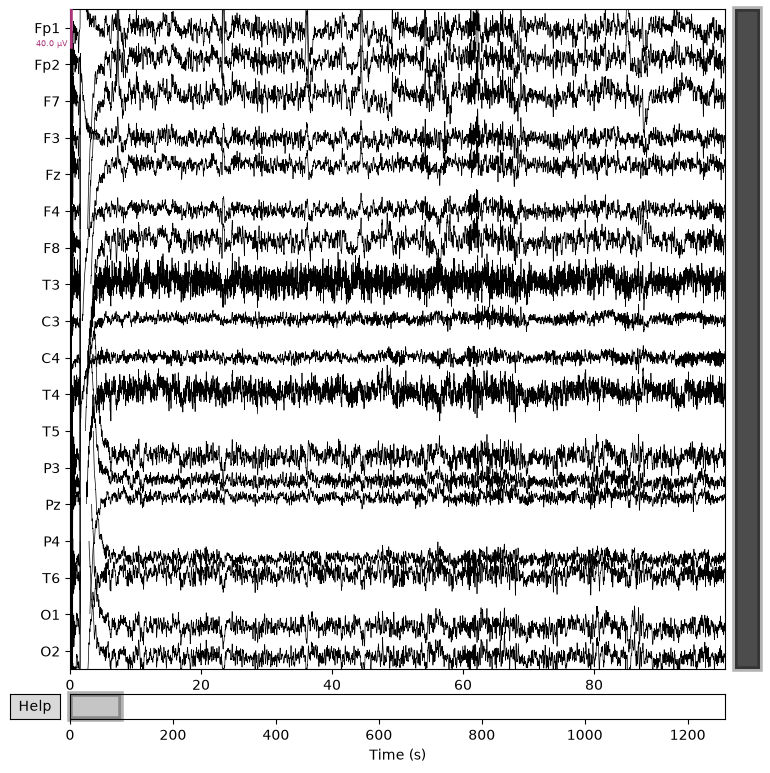

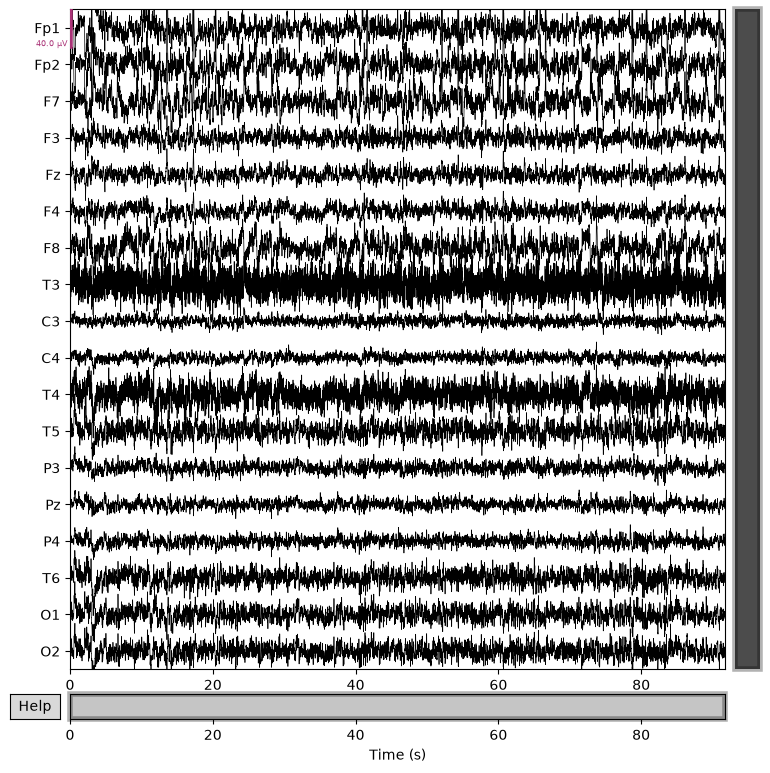

In [230]:
# plots of the raw data for the first two sessions (first is baseline, second is main)
# as you can see, the first baseline contains a huge artifact
baseline_raw[0].plot(duration=100);
main_raw[0].plot(duration=100);

In [231]:
# add T3-Cz to bad channels due to the high noise
for raw in baseline_raw:
    raw.info["bads"].append("T3")
    raw.info["bads"].append("T4")
for raw in main_raw:
    raw.info["bads"].append("T3")
    raw.info["bads"].append("T4")

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


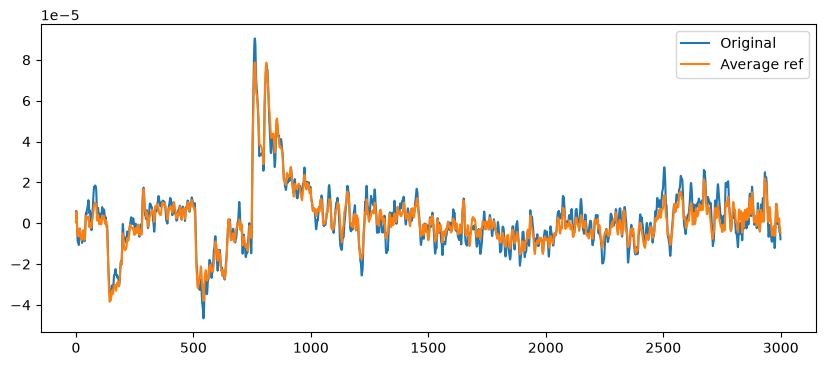

In [232]:
# re-referencing example of the difference (session 2026-04-04_L..n, main, first 3000 samples)
m_1 = main_raw[0].copy()
m_2 = m_1.copy()
m_2.set_eeg_reference(ref_channels='average') 
orig = m_1.get_data()[0]
ref = m_2.get_data()[0]
plt.figure(figsize=(10,4))
plt.plot(orig[:3000], label='Original')
plt.plot(ref[:3000], label='Average ref')
plt.legend()
plt.show()

In [233]:
# full dataset re-referencing
baseline_ref = [raw.copy() for raw in baseline_raw]
main_ref = [raw.copy() for raw in main_raw]
for baseline in baseline_ref:
    baseline.set_eeg_reference(ref_channels='average') 
for main in main_ref:
    main.set_eeg_reference(ref_channels='average')


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
E

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.7 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.70
- Lower transition bandwidth: 0.70 Hz (-6 dB cutoff frequency: 0.35 Hz)
- Filter length: 557 samples (4.718 s)



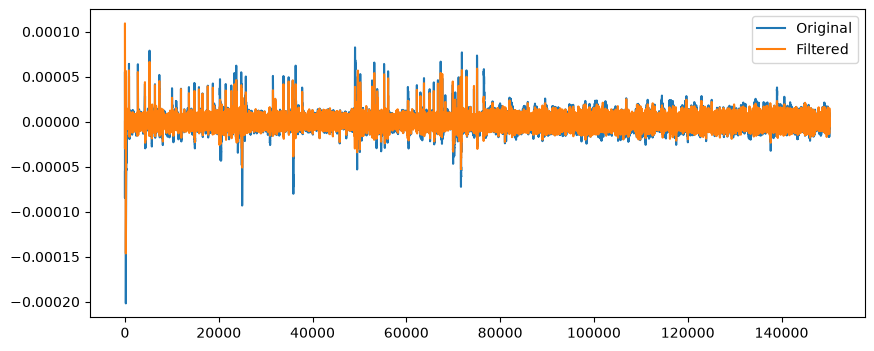

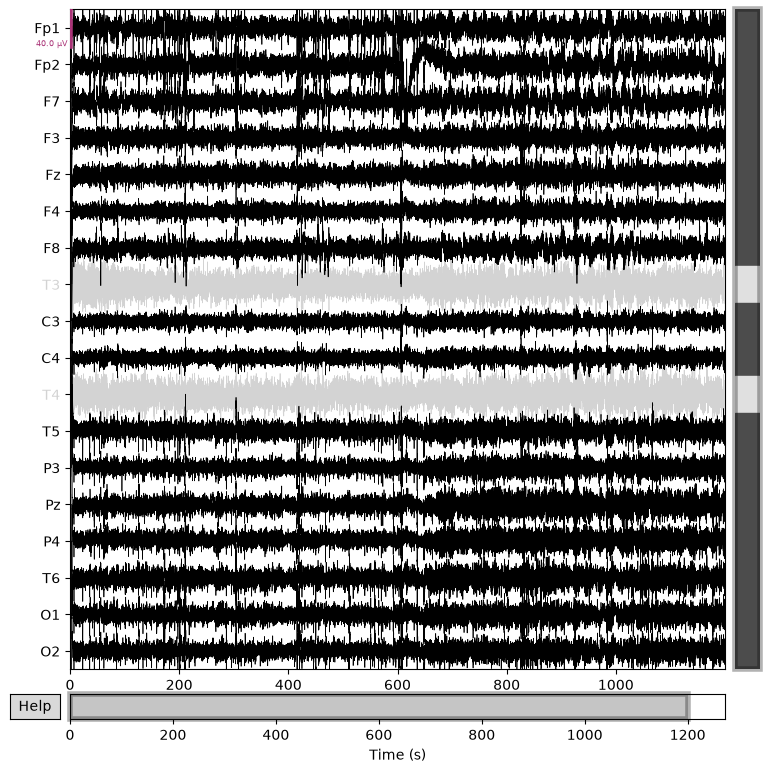

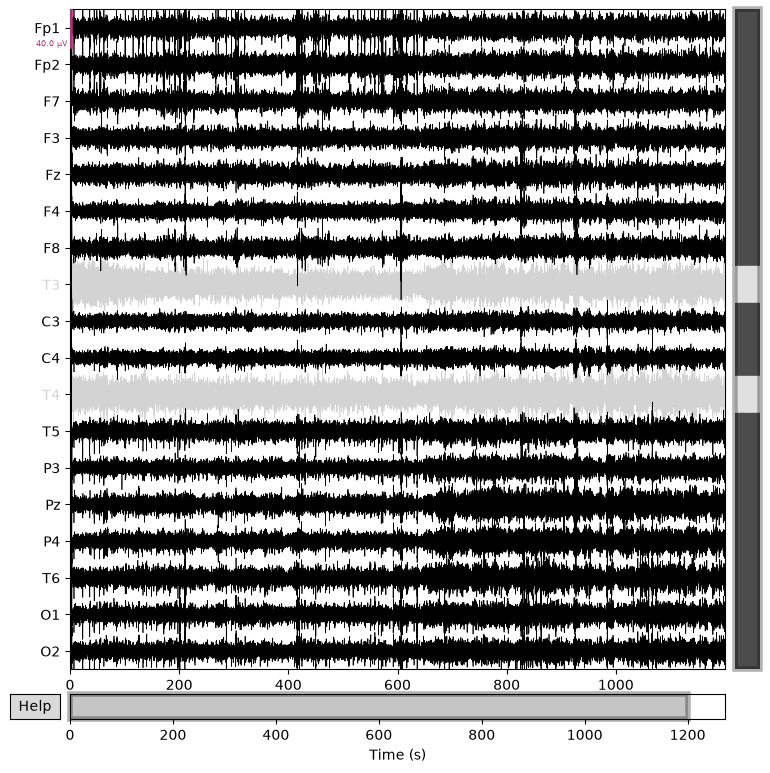

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.7 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.70
- Lower transition bandwidth: 0.70 Hz (-6 dB cutoff frequency: 0.35 Hz)
- Filter length: 557 samples (4.718 s)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.7 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.70
- Lower transition bandwidth: 0.70 Hz (-6 dB cutoff frequency: 0.35 Hz)
- Filter length: 1177 samples (4.715 s)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.7 Hz

FIR filter parame

In [234]:
# apply highpass filter (0.7 Hz)
# remove low-frequency drifts 

baseline_hband = [raw.copy() for raw in baseline_ref]
main_hband = [raw.copy() for raw in main_ref]

# example: (session 2026-04-04_L..n, baseline, full time 1200s; 
# first picture is raw, second is filtered)
b_high = baseline_hband[0].copy().filter(l_freq=0.7, h_freq=None)
orig = baseline_hband[0].get_data()[0]
ref = b_high.get_data()[0]
plt.figure(figsize=(10,4))
plt.plot(orig[:], label='Original')
plt.plot(ref[:], label='Filtered')
plt.legend()
plt.show()
fig_orig = baseline_hband[0].copy().plot(
    duration=1200, proj=False, n_channels=len(baseline_hband[0].ch_names), remove_dc=False
);
fig = b_high.plot(
    duration=1200, proj=False, n_channels=len(b_high.ch_names), remove_dc=False
);
fig_orig.subplots_adjust(top=0.9)
fig_orig.suptitle(f"Raw data", size="xx-large", weight="bold")
fig.subplots_adjust(top=0.9)
fig.suptitle(f"High-pass filtered at {0.7} Hz", size="xx-large", weight="bold")

# apply highpass filter on the whole dataset
baseline_hband = [raw.copy().filter(l_freq=0.7, h_freq=None) for raw in baseline_hband]
main_hband = [raw.copy().filter(l_freq=0.7, h_freq=None) for raw in main_hband]

Effective window size : 8.213 (s)


Plotting power spectral density (dB=True).


/Users/fountainer/.pyenv/versions/eeg-to-code/lib/python3.14/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


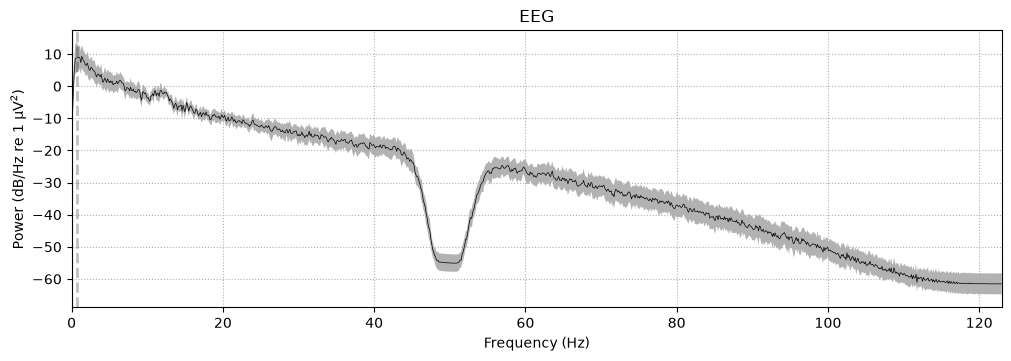

In [235]:
# powerline noise (notch filter)

# as we can see, the signal already has a deep in 50Hz freq, so it seems that the notch filter has already been applied
fig = main_hband[0].compute_psd(fmax=123).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 99 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 99.25
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 99.00 Hz)
- Upper passband edge: 100.75 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 101.00 Hz)
- Filter length: 1649 samples (6.605 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 99 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 99.25
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 99.00 Hz)
- Upper pa

/Users/fountainer/.pyenv/versions/eeg-to-code/lib/python3.14/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


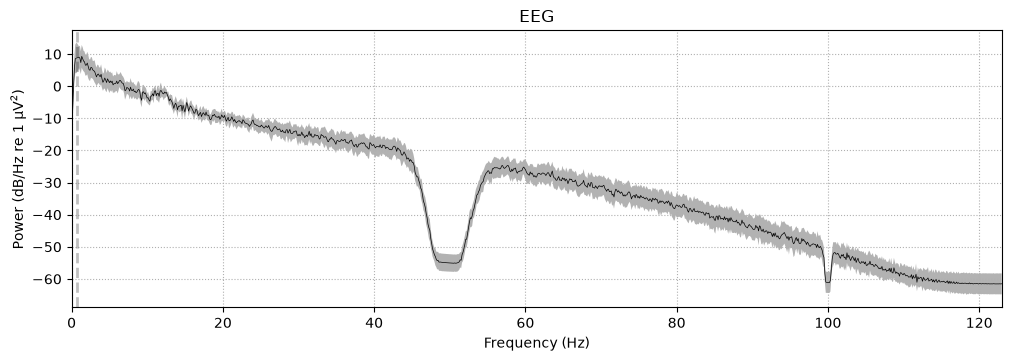

In [237]:
# I additionally apply the notch filter for the first 50Hz harmonic (100Hz)

# I skip the first baseline, since its sampling frequency is too low to use 100Hz

baseline_notch = [baseline_hband[0]] + [raw.copy().notch_filter(freqs=(100), picks=("eeg")) for raw in baseline_hband[1:]]
main_notch = [raw.copy().notch_filter(freqs=(100), picks=("eeg")) for raw in main_hband]

fig = main_notch[0].compute_psd(fmax=123).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
)


Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 75 samples (0.301 s)



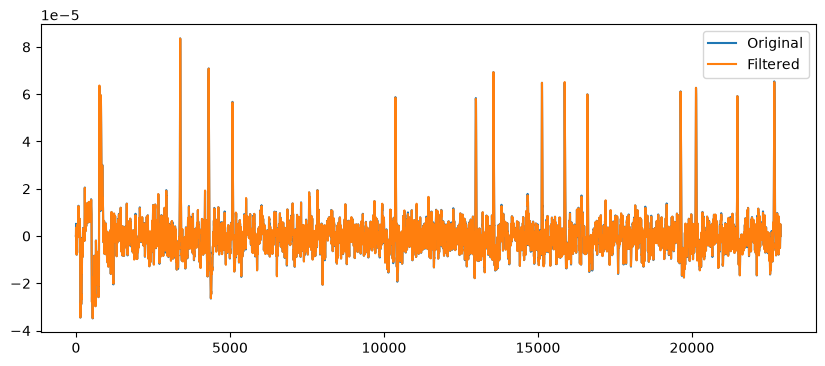

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 35 samples (0.296 s)

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 75 samples (0.300 s)

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 45 Hz

FIR filter param

In [238]:
# apply lowpass filter (50Hz)

baseline_lband = [raw.copy() for raw in baseline_notch]
main_lband = [raw.copy() for raw in main_notch]

# example: (session 2026-04-04_L..n, baseline; 
# first picture is raw, second is filtered)
b_low = main_lband[0].copy().filter(l_freq=None, h_freq=45)
orig = main_lband[0].get_data()[0]
ref = b_low.get_data()[0]
plt.figure(figsize=(10,4))
plt.plot(orig[:], label='Original')
plt.plot(ref[:], label='Filtered')
plt.legend()
plt.show()

# apply highpass filter on the whole dataset
baseline_lband = [raw.copy().filter(l_freq=None, h_freq=45) for raw in baseline_notch]
main_lband = [raw.copy().filter(l_freq=None, h_freq=45) for raw in main_notch]

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.6 mm
Computing interpolation matrix from 16 sensor positions
Interpolating 2 sensors


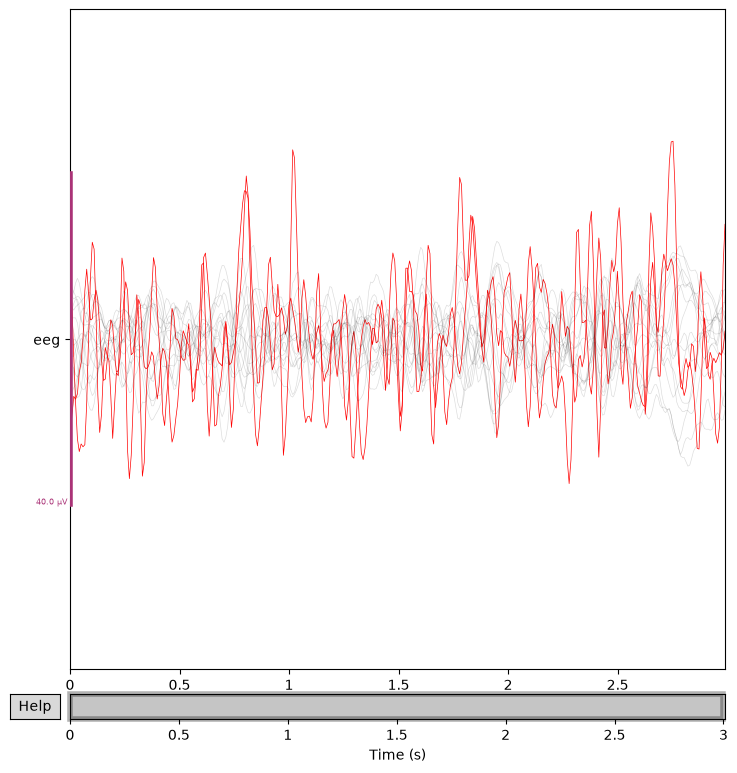

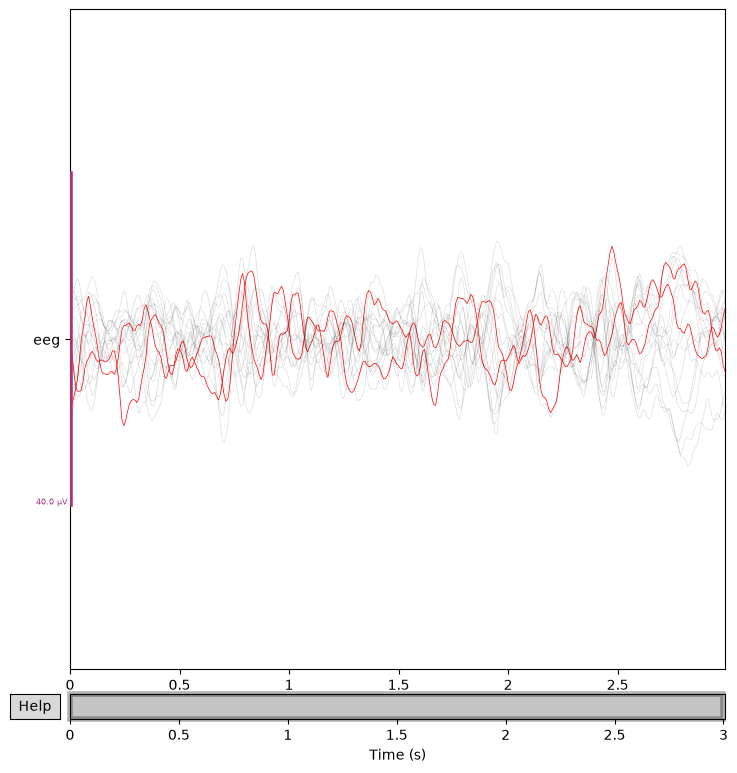

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.6 mm
Computing interpolation matrix from 16 sensor positions
Interpolating 2 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.6 mm
Computing interpolation matrix from 16 sensor positions
Interpolating 2 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.6 mm
Computing interpolation matrix from 16 sensor positions
Interpolating 2 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.6 mm
Computing interpolation matrix from 16 sensor positions
Interpolating 2 sensors
Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.6 mm


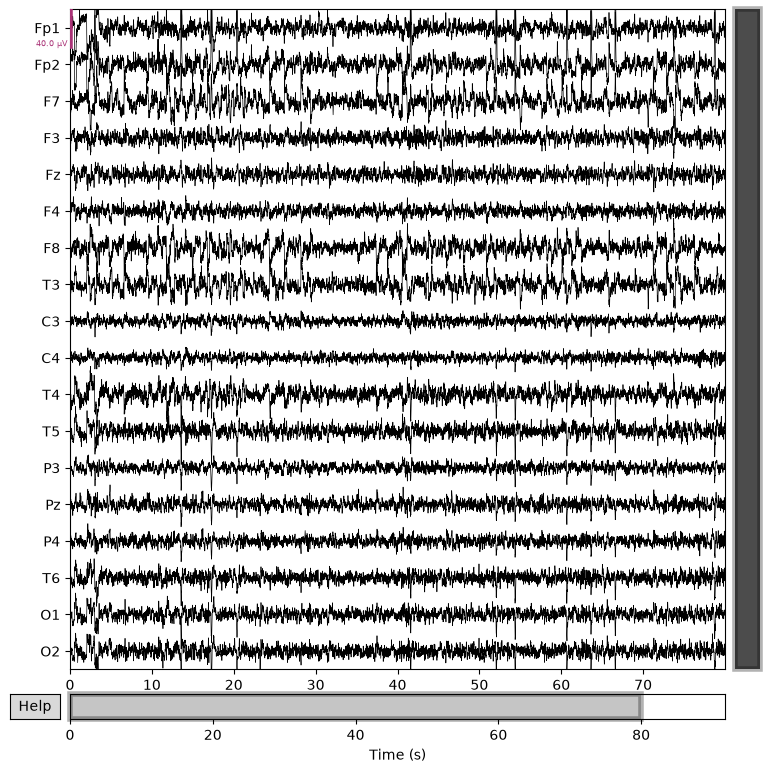

In [239]:
# channel interpolation using the spherical spline method 
# the list of manually detected bad channels: ["T3", "T4"]

# example: session 2026-04-04_L..n, baseline, full time 1200s; 

inter_ex = baseline_lband[0].copy()
inter_ex.crop(tmin=20, tmax=23).load_data()

eeg_data = inter_ex.copy().pick(picks="eeg")
eeg_data_interp = eeg_data.copy().interpolate_bads(reset_bads=False)

for title, data in zip(["orig.", "interp."], [eeg_data, eeg_data_interp]):
    fig = data.plot(butterfly=True, color="#00000022", bad_color="r");
    fig.subplots_adjust(top=0.9)
    fig.suptitle(title, size="xx-large", weight="bold")

# interpolate for all samples
baseline_interp = [raw.copy().interpolate_bads(reset_bads=True) for raw in baseline_lband]
main_interp = [raw.copy().interpolate_bads(reset_bads=True) for raw in main_lband]

main_interp[0].plot(duration=80);


Using EOG channel: Fp1
EOG channel index for this subject is: [0]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel Fp1 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 2494 samples (10.002 s)

Now detecting blinks and generating corresponding events
Found 26 significant peaks
Number of EOG events detected: 26
Not setting metadata
26 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 26 events and 51 original time points ...
0 bad epochs dropped
Using 

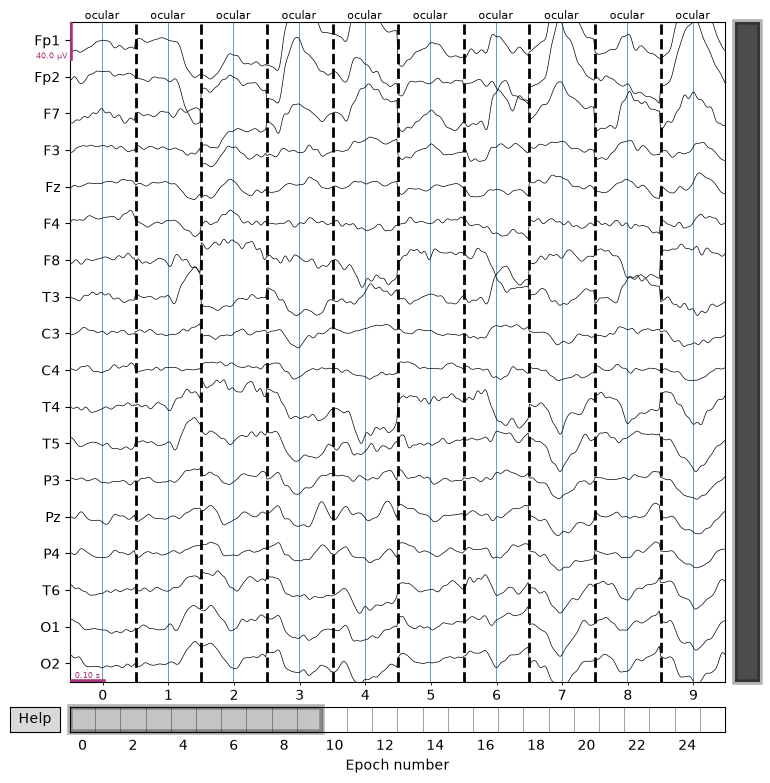

Using EOG channel: Fp1
EOG channel index for this subject is: [0]
Filtering the data to remove DC offset to help distinguish blinks from saccades
Selecting channel Fp1 for blink detection
Setting up band-pass filter from 1 - 10 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 1.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 0.75 Hz)
- Upper passband edge: 10.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 10.25 Hz)
- Filter length: 1181 samples (10.004 s)

Now detecting blinks and generating corresponding events
Found 25 significant peaks
Number of EOG events detected: 25
Not setting metadata
25 matching events found
No baseline correction applied
0 projection items activated
Using EOG channel: Fp1
EOG channel index for this subject is: [0]
Filtering the data to remove DC offse

In [300]:
# blink artifact detection

baseline_eog = [raw.copy() for raw in baseline_interp]
main_eog = [raw.copy() for raw in main_interp]

# example: Fp1 channel is used as a reference for eye blinks artifacts since it is close to the eye
# Fp2 channels is not used since it introduces two times more artifacts than Fp2 and it can contain valuable data
event_dict = {
    "ocular": 998,
}
eog_events_ex = mne.preprocessing.find_eog_events(main_eog[0], event_id=998, ch_name="Fp1")
# no baseline correction now because ICA can introduce DC offsets
eog_epochs_ex = mne.Epochs(main_eog[0], baseline=None, tmin=-0.1, tmax=0.1, events=eog_events_ex, event_id=event_dict)
eog_epochs_ex.plot(events=True, n_epochs=10, event_id=True);

# detect all blink artifacts in each session
bs_eog_events = []
bs_eog_epochs = []
mn_eog_events = []
mn_eog_epochs = []
for session in baseline_eog:
    eog_events = mne.preprocessing.find_eog_events(session, event_id=998, ch_name="Fp1")
    eog_epochs = mne.Epochs(session, baseline=None, tmin=-0.1, tmax=0.1, events=eog_events, event_id=event_dict)
    bs_eog_events.append(eog_events)
    bs_eog_epochs.append(eog_epochs)
for session in main_eog:
    eog_events = mne.preprocessing.find_eog_events(session, event_id=998, ch_name="Fp1")
    eog_epochs = mne.Epochs(session, baseline=None, tmin=-0.1, tmax=0.1, events=eog_events, event_id=event_dict)
    mn_eog_events.append(eog_events)
    mn_eog_epochs.append(eog_epochs)
